In [ ]:
#Mount Drive
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


In [ ]:
#Set Paths & Constants
BASE = "/content/drive/MyDrive/Dataset/SOCOFing"
IMG_SIZE = 224
BATCH = 16
SEED = 42
ALTERED_SAMPLE_COUNT = 4000

In [ ]:
#import libraries

import os
import shutil
import random
import pandas as pd
import numpy as np
import cv2
import tensorflow as tf
from tqdm import tqdm

random.seed(SEED)
AUTOTUNE = tf.data.AUTOTUNE


In [ ]:
#Collect Altered Images (Easy + Medium + Hard)

altered_easy = os.path.join(BASE, "Altered-Easy")
altered_med = os.path.join(BASE, "Altered-Medium")
altered_hard = os.path.join(BASE, "Altered-Hard")

altered_out = os.path.join(BASE, "Altered")
os.makedirs(altered_out, exist_ok=True)

def list_imgs(folder):
    return [
        os.path.join(folder, f)
        for f in os.listdir(folder)
        if f.lower().endswith((".bmp", ".jpg", ".jpeg", ".png"))
    ]

all_altered = list_imgs(altered_easy) + list_imgs(altered_med) + list_imgs(altered_hard)

sampled_altered = random.sample(all_altered, ALTERED_SAMPLE_COUNT)

for p in sampled_altered:
    dst = os.path.join(altered_out, os.path.basename(p))
    if not os.path.exists(dst):
        shutil.copy(p, dst)

print("Altered count:", len(os.listdir(altered_out)))


Altered count: 3709


In [ ]:
#Sample Real Images

real_path = os.path.join(BASE, "Real")
real_out = os.path.join(BASE, "Real_sampled")
os.makedirs(real_out, exist_ok=True)

real_files = [
    os.path.join(real_path, f)
    for f in os.listdir(real_path)
    if f.lower().endswith((".bmp",".jpg",".jpeg",".png"))
]

from collections import defaultdict

by_person = defaultdict(list)

def get_pid(f):
    return os.path.basename(f).split("__")[0]

for f in real_files:
    by_person[get_pid(f)].append(f)

selected = []

for pid, files in by_person.items():
    selected.append(random.choice(files))

need = ALTERED_SAMPLE_COUNT - len(selected)

if need > 0:
    remaining = [f for f in real_files if f not in selected]
    selected += remaining[:need]

if len(selected) > ALTERED_SAMPLE_COUNT:
    selected = random.sample(selected, ALTERED_SAMPLE_COUNT)

for p in selected:
    dst = os.path.join(real_out, os.path.basename(p))
    if not os.path.exists(dst):
        shutil.copy(p, dst)

print("Real sample count:", len(os.listdir(real_out)))


Real sample count: 4000


In [ ]:
#Build DataFrame

def parse_meta(fp, is_altered):
    fname = os.path.basename(fp)

    person = fname.split("__")[0]

    parts = fname.replace(".BMP","").split("_")

    gender="U"
    hand="U"
    finger="unknown"

    for p in parts:
        if p.upper() in ("M","F"):
            gender = p.upper()
        if p.lower() in ("left","right"):
            hand = p.capitalize()
        if p.lower() in ("thumb","index","middle","ring","little"):
            finger = p.lower()

    return {
        "filepath": fp,
        "person": person,
        "gender": gender,
        "hand": hand,
        "finger": finger,
        "live": 1 if is_altered else 0
    }

real_df = pd.DataFrame([
    parse_meta(os.path.join(real_out,f), False)
    for f in os.listdir(real_out)
    if f.lower().endswith((".bmp",".jpg",".jpeg",".png"))
])

alt_df = pd.DataFrame([
    parse_meta(os.path.join(altered_out,f), True)
    for f in os.listdir(altered_out)
    if f.lower().endswith((".bmp",".jpg",".jpeg",".png"))
])

df = pd.concat([real_df, alt_df], ignore_index=True)
df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)

print(df.head())
print("Total samples:", len(df))


                                            filepath person gender   hand  \
0  /content/drive/MyDrive/Dataset/SOCOFing/Altere...    572      F  Right   
1  /content/drive/MyDrive/Dataset/SOCOFing/Altere...    212      M  Right   
2  /content/drive/MyDrive/Dataset/SOCOFing/Altere...     83      M   Left   
3  /content/drive/MyDrive/Dataset/SOCOFing/Real_s...    471      M  Right   
4  /content/drive/MyDrive/Dataset/SOCOFing/Altere...    364      M  Right   

   finger  live  
0  little     1  
1    ring     1  
2  little     1  
3   index     0  
4    ring     1  
Total samples: 7709


In [ ]:
#Train/Val/Test Split

from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df, test_size=0.15, stratify=df["live"], random_state=SEED
)

train_df, val_df = train_test_split(
    train_df, test_size=0.1764, stratify=train_df["live"], random_state=SEED
)

print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))


Train: 5396
Val: 1156
Test: 1157


In [ ]:
gender_map = {"M":0, "F":1, "U":2}
hand_map = {"Left":0, "Right":1, "U":2}

finger_classes = sorted(train_df["finger"].unique())
finger_map = {f:i for i,f in enumerate(finger_classes)}

print("Finger classes:", finger_map)

def preprocess_np(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
    g = clahe.apply(gray)
    g = cv2.resize(g, (IMG_SIZE, IMG_SIZE))
    rgb = np.repeat(g[:, :, None], 3, axis=-1)
    return rgb.astype("float32") / 255.0

def load_image_np(path, live, gender, hand, finger):
    path = path.decode()
    img = cv2.imread(path)
    if img is None:
        img = np.zeros((IMG_SIZE,IMG_SIZE,3), dtype="float32")
    else:
        img = preprocess_np(img)
    # Ensure live label is float32 and reshaped to (1,) for binary_crossentropy
    return img, np.int32(live), np.int32(gender), np.int32(hand), np.int32(finger)


def load_image_tf(path, live, gender, hand, finger):

    img, l, g, h, f = tf.numpy_function(
        load_image_np,
        [path, live, gender, hand, finger],
        [tf.float32, tf.int32, tf.int32, tf.int32, tf.int32]
    )

    img.set_shape([IMG_SIZE, IMG_SIZE, 3])


    l = tf.cast(l, tf.float32)
    l = tf.reshape(l, (1,))     # shape = (1,) OK

    g = tf.reshape(g, ())
    h = tf.reshape(h, ())
    f = tf.reshape(f, ())

    return img, {
        "live_output": l,
        "gender_output": g,
        "hand_output": h,
        "finger_output": f
    }


def make_dataset(df_in, shuffle=False, augment=True):
    df_in = df_in[df_in["filepath"].apply(os.path.isfile)]

    paths  = df_in["filepath"].values.astype(str)
    live   = df_in["live"].values
    gender = [gender_map[g] for g in df_in["gender"]]
    hand   = [hand_map[h] for h in df_in["hand"]]
    finger = [finger_map[f] for f in df_in["finger"]]

    ds = tf.data.Dataset.from_tensor_slices((paths, live, gender, hand, finger))

    if shuffle:
        ds = ds.shuffle(len(paths), seed=SEED)

    ds = ds.map(load_image_tf, num_parallel_calls=AUTOTUNE)

    if augment:
        ds = ds.map(lambda x,y: (tf.image.random_flip_left_right(x), y))
        ds = ds.map(lambda x,y: (tf.image.random_contrast(x,0.7,1.3), y))

    ds = ds.batch(BATCH, drop_remainder=True)   # <-- IMPORTANT
    ds = ds.prefetch(AUTOTUNE)

    return ds


train_ds = make_dataset(train_df, shuffle=True, augment=True)
val_ds   = make_dataset(val_df, shuffle=False, augment=False)
test_ds  = make_dataset(test_df, shuffle=False, augment=False)

print("Datasets created successfully.")

Finger classes: {'index': 0, 'little': 1, 'middle': 2, 'ring': 3, 'thumb': 4}
Datasets created successfully.


In [ ]:
for x, y in train_ds.take(1):
    print("Image batch:", x.shape)
    print("Live:", y["live_output"].shape, y["live_output"].dtype)
    print("Gender:", y["gender_output"].shape)
    print("Hand:", y["hand_output"].shape)
    print("Finger:", y["finger_output"].shape)


Image batch: (16, 224, 224, 3)
Live: (16, 1) <dtype: 'float32'>
Gender: (16,)
Hand: (16,)
Finger: (16,)


In [ ]:
#CBAM Attention + EfficientNetB0 Model

from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB0

def cbam_block(x, reduction=8):

    # ===== CHANNEL ATTENTION =====
    channel_dim = x.shape[-1]

    avg_pool = layers.GlobalAveragePooling2D()(x)
    avg_pool = layers.Dense(channel_dim // reduction, activation="relu")(avg_pool)
    avg_pool = layers.Dense(channel_dim)(avg_pool)

    max_pool = layers.GlobalMaxPooling2D()(x)
    max_pool = layers.Dense(channel_dim // reduction, activation="relu")(max_pool)
    max_pool = layers.Dense(channel_dim)(max_pool)

    channel_attention = layers.Add()([avg_pool, max_pool])
    channel_attention = layers.Activation("sigmoid")(channel_attention)
    channel_attention = layers.Reshape((1,1,channel_dim))(channel_attention)

    x = layers.Multiply()([x, channel_attention])

    # ===== SPATIAL ATTENTION =====
    avg_spatial = layers.Lambda(lambda t: tf.reduce_mean(t, axis=3, keepdims=True))(x)
    max_spatial = layers.Lambda(lambda t: tf.reduce_max(t, axis=3, keepdims=True))(x)

    spatial = layers.Concatenate(axis=3)([avg_spatial, max_spatial])
    spatial = layers.Conv2D(1, kernel_size=7, padding="same", activation="sigmoid")(spatial)

    x = layers.Multiply()([x, spatial])

    return x


# -------------------------
# EfficientNet + CBAM Model
# -------------------------
base = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
base.trainable = False

inp = layers.Input((IMG_SIZE, IMG_SIZE, 3))

x = base(inp, training=False)
x = cbam_block(x)              # <-- FIXED
x = layers.GlobalAveragePooling2D()(x)

x = layers.Dense(1024, activation="relu")(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(512, activation="relu")(x)

live_out   = layers.Dense(1, activation="sigmoid", name="live_output")(x)
gender_out = layers.Dense(len(gender_map), activation="softmax", name="gender_output")(x)
hand_out   = layers.Dense(len(hand_map), activation="softmax", name="hand_output")(x)
finger_out = layers.Dense(len(finger_map), activation="softmax", name="finger_output")(x)

model = Model(inp, [live_out, gender_out, hand_out, finger_out])

model.compile(
    optimizer="adam",
    loss={
        "live_output": "binary_crossentropy",
        "gender_output": "sparse_categorical_crossentropy",
        "hand_output": "sparse_categorical_crossentropy",
        "finger_output": "sparse_categorical_crossentropy",
    },
    metrics={
        "live_output": ["accuracy"],
        "gender_output": ["accuracy"],
        "hand_output": ["accuracy"],
        "finger_output": ["accuracy"],
    }
)


model.summary()


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetb0      │ (None, 7, 7,      │  4,049,571 │ input_layer_1[0]… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ efficientnetb0[0… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 1280)      │          0 │ efficientnetb0[0… │
│ (GlobalMaxPooling2… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 160)       │    204,960 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 160)       │    204,960 │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1280)      │    206,080 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1280)      │    206,080 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 1280)      │          0 │ dense_1[0][0],    │
│                     │                   │            │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 1280)      │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 1,      │          0 │ activation[0][0]  │
│                     │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 7, 7,      │          0 │ efficientnetb0[0… │
│                     │ 1280)             │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 7, 7, 1)   │          0 │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 7, 7, 1)   │          0 │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 7, 7, 2)   │          0 │ lambda[0][0],     │
│ (Concatenate)       │                   │            │ lambda_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 7, 7, 1)   │         99 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_1          │ (None, 7, 7,      │          0 │ multiply[0][0],   │
│ (Multiply)          │ 1280)             │            │ conv2d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ multiply_1[0][0]  │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 1024)      │  1,311,744 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 6,714,450 (25.61 MB)

 Trainable params: 2,664,879 (10.17 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
for batch in train_ds.take(1):
    print(batch[0].shape, batch[1]["live_output"].shape)



(16, 224, 224, 3) (16, 1)


In [ ]:
for batch in val_ds.take(1):
    print("Val batch shapes:")
    print(batch[0].shape)
    print(batch[1]["live_output"].shape)


Val batch shapes:
(16, 224, 224, 3)
(16, 1)


In [ ]:
broken = []
for p in df["filepath"]:
    if not os.path.isfile(p):
        broken.append(p)

print("Broken paths:", len(broken))


Broken paths: 0


In [ ]:
#Training

from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

checkpoint = ModelCheckpoint(
    BASE + "/best_cbam_model.keras",
    save_best_only=True,
    monitor="val_live_output_loss",
    mode="min"
)

early = EarlyStopping(
    monitor="val_live_output_loss",
    patience=5,
    restore_best_weights=True,
    mode="min"
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_live_output_loss",
    factor=0.3,
    patience=2,
    mode="min"
)

steps_per_epoch = len(train_df)//BATCH
val_steps = len(val_df)//BATCH

history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    steps_per_epoch=steps_per_epoch,
    validation_steps=val_steps,
    epochs=12,
    callbacks=[checkpoint, early, reduce_lr]
)


Epoch 1/12
337/337 ━━━━━━━━━━━━━━━━━━━━ 861s 2s/step - finger_output_accuracy: 0.2204 - finger_output_loss: 1.6245 - gender_output_accuracy: 0.7806 - gender_output_loss: 0.5603 - hand_output_accuracy: 0.4995 - hand_output_loss: 0.7275 - live_output_accuracy: 0.5059 - live_output_loss: 0.7015 - loss: 3.6137 - val_finger_output_accuracy: 0.2014 - val_finger_output_loss: 1.6130 - val_gender_output_accuracy: 0.8038 - val_gender_output_loss: 0.4957 - val_hand_output_accuracy: 0.5217 - val_hand_output_loss: 0.6935 - val_live_output_accuracy: 0.5191 - val_live_output_loss: 0.6931 - val_loss: 3.4953 - learning_rate: 0.0010
Epoch 2/12
337/337 ━━━━━━━━━━━━━━━━━━━━ 563s 2s/step - finger_output_accuracy: 0.1945 - finger_output_loss: 1.6151 - gender_output_accuracy: 0.7899 - gender_output_loss: 0.5190 - hand_output_accuracy: 0.5066 - hand_output_loss: 0.6975 - live_output_accuracy: 0.5075 - live_output_loss: 0.6944 - loss: 3.5260 - val_finger_output_accuracy: 0.1780 - val_finger_output_loss: 1.6185

In [ ]:
# Unfreeze top EfficientNet layers for fine-tuning
base.trainable = True

# Freeze bottom layers; allow learning only on top ~80 layers
for layer in base.layers[:-80]:
    layer.trainable = False

# Re-compile with lower learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(3e-6),
    loss={
        "live_output": "binary_crossentropy",
        "gender_output": "sparse_categorical_crossentropy",
        "hand_output": "sparse_categorical_crossentropy",
        "finger_output": "sparse_categorical_crossentropy",
    },
    metrics={
        "live_output": ["accuracy"],
        "gender_output": ["accuracy"],
        "hand_output": ["accuracy"],
        "finger_output": ["accuracy"],
    }
)

history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    steps_per_epoch=steps_per_epoch,
    validation_steps=val_steps,
    epochs=10,
    callbacks=[checkpoint, early, reduce_lr]
)


Epoch 1/10
337/337 ━━━━━━━━━━━━━━━━━━━━ 748s 2s/step - finger_output_accuracy: 0.2390 - finger_output_loss: 1.6102 - gender_output_accuracy: 0.7971 - gender_output_loss: 0.5211 - hand_output_accuracy: 0.5264 - hand_output_loss: 0.6944 - live_output_accuracy: 0.5277 - live_output_loss: 0.6930 - loss: 3.5188 - val_finger_output_accuracy: 0.2188 - val_finger_output_loss: 1.6149 - val_gender_output_accuracy: 0.8038 - val_gender_output_loss: 0.5565 - val_hand_output_accuracy: 0.5260 - val_hand_output_loss: 0.6966 - val_live_output_accuracy: 0.4835 - val_live_output_loss: 0.6968 - val_loss: 3.5648 - learning_rate: 3.0000e-06
Epoch 2/10
337/337 ━━━━━━━━━━━━━━━━━━━━ 720s 2s/step - finger_output_accuracy: 0.2741 - finger_output_loss: 1.5708 - gender_output_accuracy: 0.7933 - gender_output_loss: 0.5136 - hand_output_accuracy: 0.5607 - hand_output_loss: 0.6872 - live_output_accuracy: 0.5169 - live_output_loss: 0.6958 - loss: 3.4674 - val_finger_output_accuracy: 0.3316 - val_finger_output_loss: 1.

=== Model Evaluation (Live vs Fake) ===
Accuracy:  0.5295
Precision: 0.5111
Recall:    0.5387
F1 Score:  0.5246

=== Classification Report ===
              precision    recall  f1-score   support

        Real       0.55      0.52      0.53       597
        Fake       0.51      0.54      0.52       555

    accuracy                           0.53      1152
   macro avg       0.53      0.53      0.53      1152
weighted avg       0.53      0.53      0.53      1152



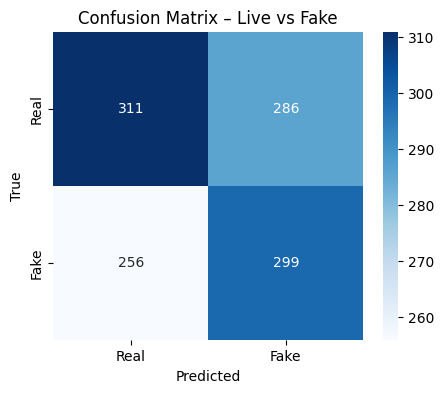

In [ ]:
from sklearn.metrics import (
    confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score,
    classification_report
)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load best model weights
model.load_weights(BASE + "/best_cbam_model.keras")

true_labels = []
pred_labels = []

# Predict on full test dataset
for x, y in test_ds.take(len(test_df)//BATCH + 1):
    preds = model.predict(x, verbose=0)
    live_probs = preds[0].flatten()        # sigmoid output for live/spoof

    pred_labels.extend((live_probs > 0.5).astype(int))  # threshold at 0.5
    true_labels.extend(y["live_output"].numpy().flatten())

# Trim if mismatch
true_labels = true_labels[:len(pred_labels)]

# -----------------------------
# Evaluation Metrics
# -----------------------------
acc = accuracy_score(true_labels, pred_labels)
prec = precision_score(true_labels, pred_labels, zero_division=0)
rec = recall_score(true_labels, pred_labels, zero_division=0)
f1 = f1_score(true_labels, pred_labels, zero_division=0)

print("=== Model Evaluation (Live vs Fake) ===")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 Score:  {f1:.4f}")

# -----------------------------
# Classification Report
# -----------------------------
print("\n=== Classification Report ===")
print(classification_report(true_labels, pred_labels,
                            target_names=["Real", "Fake"],
                            zero_division=0))

# -----------------------------
# Confusion Matrix
# -----------------------------
cm = confusion_matrix(true_labels, pred_labels)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm, annot=True, cmap="Blues", fmt="d",
    xticklabels=["Real", "Fake"],
    yticklabels=["Real", "Fake"]
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix – Live vs Fake")
plt.show()


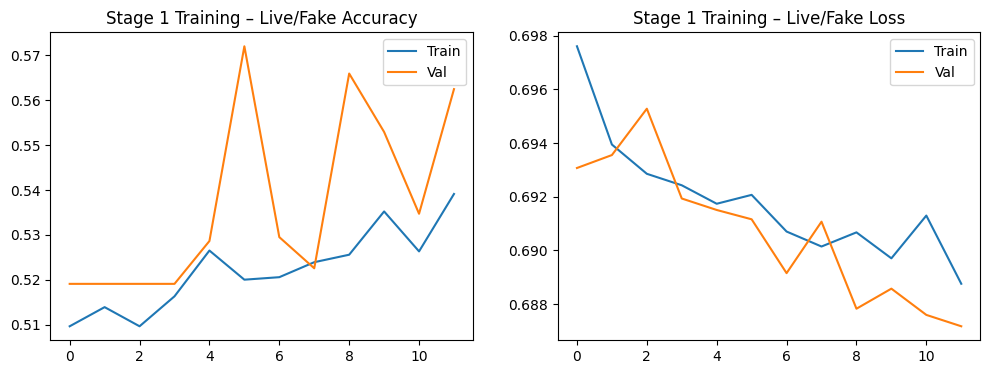

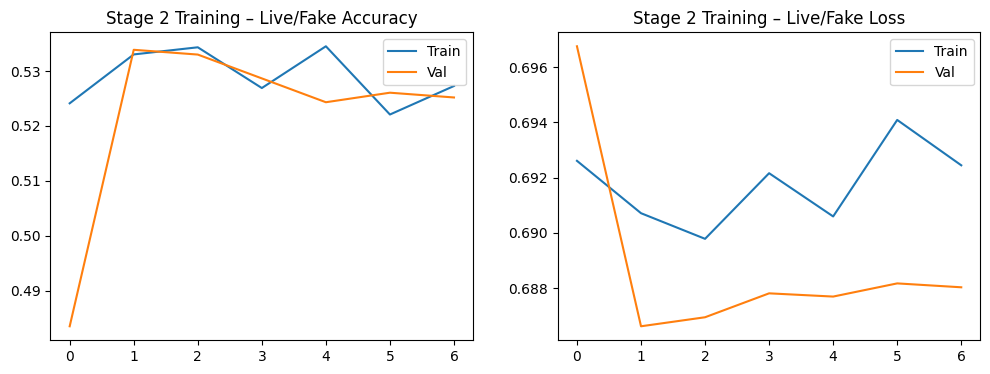

In [ ]:
def plot_history(history, title):
    plt.figure(figsize=(12,4))

    # Accuracy
    plt.subplot(1,2,1)
    plt.plot(history.history["live_output_accuracy"], label="Train")
    plt.plot(history.history["val_live_output_accuracy"], label="Val")
    plt.title(title + " – Live/Fake Accuracy")
    plt.legend()

    # Loss
    plt.subplot(1,2,2)
    plt.plot(history.history["live_output_loss"], label="Train")
    plt.plot(history.history["val_live_output_loss"], label="Val")
    plt.title(title + " – Live/Fake Loss")
    plt.legend()

    plt.show()

plot_history(history1, "Stage 1 Training")
plot_history(history2, "Stage 2 Training")


In [ ]:
def predict_image(path):
    img = cv2.imread(path)
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
    clahe = cv2.createCLAHE(3.0,(8,8))
    g = clahe.apply(gray)
    g = cv2.resize(g, (IMG_SIZE, IMG_SIZE))

    inp = np.repeat(g[:, :, None], 3, axis=-1).astype("float32")/255.0

    preds = model.predict(np.expand_dims(inp, axis=0))

    live = preds[0][0][0]
    gender = list(gender_map.keys())[np.argmax(preds[1])]
    hand = list(hand_map.keys())[np.argmax(preds[2])]
    finger = list(finger_map.keys())[np.argmax(preds[3])]

    print("Live/Fake:", "Fake" if live > 0.5 else "Real")
    print("Gender:", gender)
    print("Hand:", hand)
    print("Finger:", finger)

# Example:
predict_image("/content/drive/MyDrive/Dataset/SOCOFing/Altered/1__M_Left_little_finger_Obl.BMP")
print("\n")
# Example:
predict_image("/content/drive/MyDrive/Dataset/SOCOFing/Real/3__M_Right_thumb_finger.BMP")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
Live/Fake: Fake
Gender: M
Hand: Left
Finger: little


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
Live/Fake: Real
Gender: M
Hand: Right
Finger: thumb
